<h1>🎬 CineMatch</h1>
<h4 style="color:#555; margin-top:-8px;">
User-Based Collaborative Filtering Using MovieLens Dataset
</h4>
<hr style="border:1px solid #ddd;">

<div style="background-color: #f0f4f8; padding: 20px; border-radius: 10px; border-left: 5px solid #3498db;">

<h4>🎯 Objective</h4>
Build a <strong>User-Based Collaborative Filtering</strong> recommender using the MovieLens 100K dataset — recommending movies to users based on the preferences of similar users.

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3>📂 Dataset Overview</h3>
</div>

**Dataset:** MovieLens 100K Dataset

**Files Used:** `u.data` and `u.item`  
**Dataset Source:** GroupLens Research  
**Url:** https://grouplens.org/datasets/movielens/100k/

**Ratings File (`u.data`) — Raw Features**
| Feature | Description |
| --- | --- |
| `user_id` | Unique identifier for each user |
| `movie_id` | Unique identifier for each movie |
| `rating` | User rating on a 1–5 scale |
| `timestamp` | Unix timestamp of when the rating was given |

**Movies File (`u.item`) — Raw Features**
| Feature | Description |
| --- | --- |
| `movie_id` | Unique identifier for each movie |
| `movie_title` | Official movie title with release year |
| `release_date` | Date the movie was released |
| `imdb_url` | Direct IMDb URL for the movie |
| `genre columns` | Binary columns (0/1) for each of 19 genres |

**Downloading & Importing the Required Files**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
import plotly.express as px
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [2]:
# Load ratings
ratings = pd.read_csv(".data/movielens/ml-100k/u.data",sep='\t',names=['user_id', 'movie_id', 'rating', 'timestamp'])

# Load movies
movies = pd.read_csv(".data/movielens/ml-100k/u.item",sep='|', encoding='latin-1',
    names=['movie_id', 'movie_title', 'release_date', 'video_release',
           'imdb_url', 'unknown', 'Action', 'Adventure', 'Animation',
           'Children', 'Comedy', 'Crime', 'Documentary', 'Drama',
           'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery',
           'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
)

print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)

Ratings shape: (100000, 4)
Movies shape: (1682, 24)


In [3]:
ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [4]:
movies[['movie_id', 'movie_title', 'release_date']].head()

,movie_id,movie_title,release_date
0,1,Toy Story (1995),01-Jan-1995
1,2,GoldenEye (1995),01-Jan-1995
2,3,Four Rooms (1995),01-Jan-1995
3,4,Get Shorty (1995),01-Jan-1995
4,5,Copycat (1995),01-Jan-1995


<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3>🔍 Data Quality Check</h3>
</div>

In [5]:
print("Ratings info:")
ratings.info()
print("\nMovies info:")
movies[['movie_id', 'movie_title']].info()

Ratings info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   movie_id   100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB

Movies info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1682 entries, 0 to 1681
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   movie_id     1682 non-null   int64 
 1   movie_title  1682 non-null   object
dtypes: int64(1), object(1)
memory usage: 26.4+ KB


In [6]:
print("Missing values in ratings:")
print(ratings.isna().sum())
print("\nDuplicates in ratings:", ratings.duplicated().sum())

Missing values in ratings:
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

Duplicates in ratings: 0


In [7]:
print("Unique users:",  ratings['user_id'].nunique())
print("Unique movies:", ratings['movie_id'].nunique())
print("Total ratings:", len(ratings))
print("Rating scale:",  ratings['rating'].min(), "to", ratings['rating'].max())

Unique users: 943
Unique movies: 1682
Total ratings: 100000
Rating scale: 1 to 5


<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong>Observation:</strong>
The MovieLens 100K dataset contains 100,000 ratings from 943 users across 1,682 movies. Ratings are on a 1–5 scale with no missing values — making it ideal for collaborative filtering.
</div>

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3>📊 Exploratory Data Analysis</h3>
</div>

### Distribution of Ratings

In [10]:
rating_counts = ratings['rating'].value_counts().sort_index()
labels = [i for i in rating_counts.index]

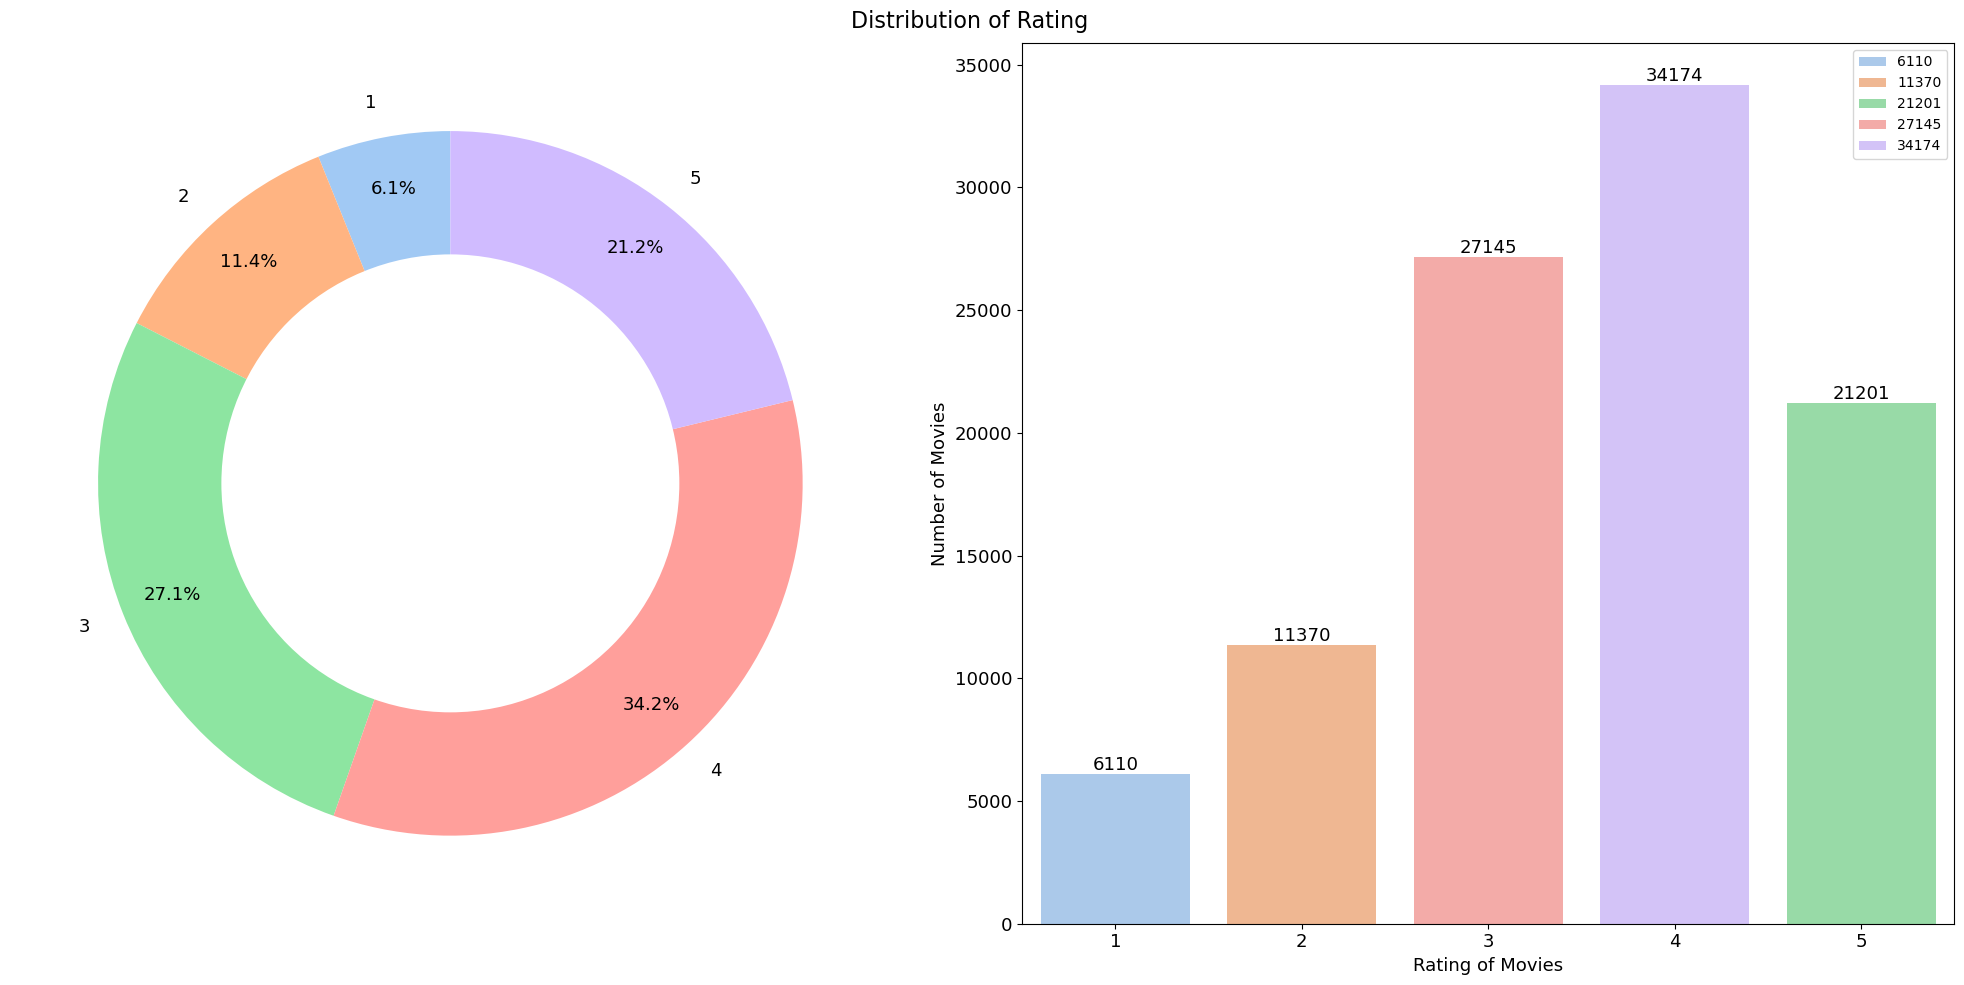

In [11]:
fig,ax = plt.subplots(1,2,figsize=(20,10))
colors = sns.color_palette("pastel", len(rating_counts))
fig.suptitle("Distribution of Rating", fontsize=16)
wedges, texts, autotexts = ax[0].pie(rating_counts,labels=labels,autopct='%1.1f%%',startangle=90,pctdistance=0.85,colors=colors)
centre_circle = plt.Circle((0,0), 0.65, fc='white')
for text in texts:
    text.set_fontsize(13)
for autotext in autotexts:
    autotext.set_fontsize(13)
ax[0].add_artist(centre_circle)
ax[1] = sns.barplot(x=labels,y=rating_counts.values,hue=rating_counts.values,palette='pastel')
for container in ax[1].containers:
    ax[1].bar_label(container,fontsize=13)
ax[1].set_xlabel("Rating of Movies",fontsize=13)
ax[1].set_ylabel("Number of Movies",fontsize=13)
ax[1].tick_params(axis='x', labelsize=13)
ax[1].tick_params(axis='y', labelsize=13)
plt.tight_layout()
plt.show()

### Ratings per User

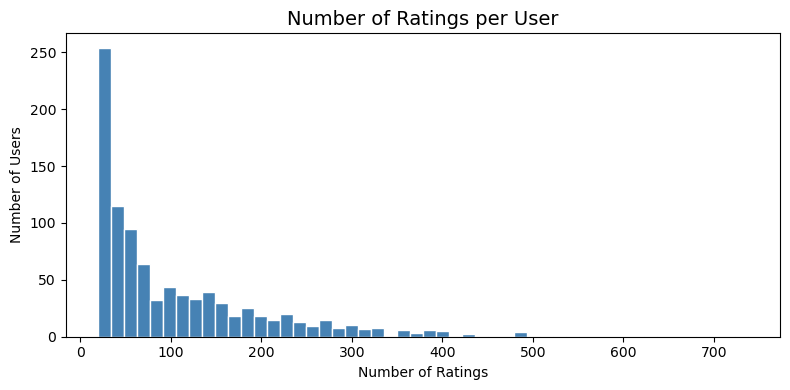

count    943.000000
mean     106.044539
std      100.931743
min       20.000000
25%       33.000000
50%       65.000000
75%      148.000000
max      737.000000
Name: rating, dtype: float64


In [12]:
ratings_per_user = ratings.groupby('user_id')['rating'].count()
plt.figure(figsize=(8, 4))
plt.hist(ratings_per_user, bins=50, color='steelblue', edgecolor='white')
plt.title("Number of Ratings per User", fontsize=14)
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()
print(ratings_per_user.describe())

### Top 10 Most Rated Movies

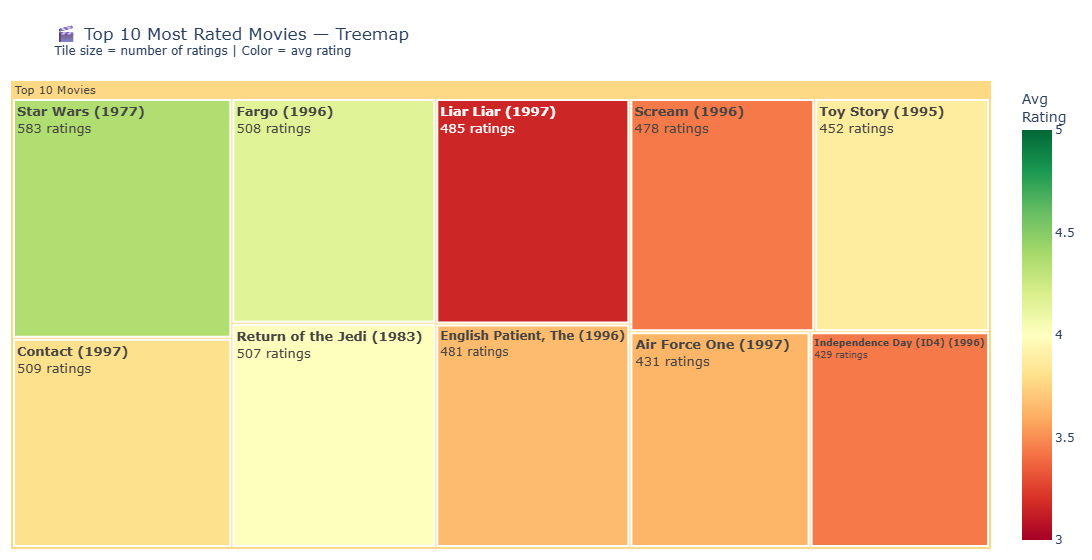

In [14]:
movie_counts = ratings.groupby('movie_id')['rating'].agg(Num_Ratings='count',Avg_Rating='mean').reset_index()
movie_counts = movie_counts.merge(movies[['movie_id', 'movie_title']], on='movie_id', how='left')
top10 = movie_counts.nlargest(10, 'Num_Ratings')
fig = px.treemap(top10,
    path=[px.Constant('Top 10 Movies'), 'movie_title'],values='Num_Ratings',color='Avg_Rating',color_continuous_scale='RdYlGn',range_color=[3.0, 5.0],
    title='🎬 Top 10 Most Rated Movies — Treemap<br>''<sup>Tile size = number of ratings | Color = avg rating</sup>')
fig.update_traces(texttemplate='<b>%{label}</b><br>%{value} ratings',textfont=dict(size=13),marker=dict(line=dict(width=2, color='white'),
                pad=dict(t=20, l=4, r=4, b=4)),hovertemplate='<b>%{label}</b><br>Ratings: %{value}<br>''Avg Rating: %{color:.2f}<extra></extra>')
fig.update_layout(height=560,margin=dict(t=80, l=10, r=10, b=10),coloraxis_colorbar=dict(title='Avg<br>Rating'))
fig.show()

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3>🧹 Data Cleaning & Preprocessing</h3>
</div>

In [15]:
# Merge ratings with movie titles
df = ratings.merge(movies[['movie_id', 'movie_title']], on='movie_id')
df = df.drop(columns=['timestamp'])  # not needed
print("Shape:", df.shape)
df.head()

Shape: (100000, 4)


,user_id,movie_id,rating,movie_title
0,196,242,3,Kolya (1996)
1,186,302,3,L.A. Confidential (1997)
2,22,377,1,Heavyweights (1994)
3,244,51,2,Legends of the Fall (1994)
4,166,346,1,Jackie Brown (1997)


<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3>🤝 Collaborative Filtering</h3>
</div>

Collaborative Filtering recommends movies based on **user behavior** — finding users with similar taste and recommending what they liked. It requires a **user × movie ratings matrix** where each cell contains a user's rating for a movie.

```
         Movie A   Movie B   Movie C
User 1     5         4          -
User 2     5         4          5    ← similar to User 1
User 3     -         2          3
```

### Step 1 — Build User-Movie Matrix

In [16]:
# Create user-movie matrix
# Rows = users, Columns = movies, Values = ratings (0 if not rated)
user_movie_matrix = df.pivot_table(index='user_id',columns='movie_title',values='rating').fillna(0)
print("User-Movie Matrix shape:", user_movie_matrix.shape)
user_movie_matrix.head()

User-Movie Matrix shape: (943, 1664)


movie_title,'Til There Was You (1997),1-900 (1994),101 Dalmatians (1996),12 Angry Men (1957),187 (1997),2 Days in the Valley (1996),"20,000 Leagues Under the Sea (1954)",2001: A Space Odyssey (1968),3 Ninjas: High Noon At Mega Mountain (1998),"39 Steps, The (1935)",...,Yankee Zulu (1994),Year of the Horse (1997),You So Crazy (1994),Young Frankenstein (1974),Young Guns (1988),Young Guns II (1990),"Young Poisoner's Handbook, The (1995)",Zeus and Roxanne (1997),unknown,Á köldum klaka (Cold Fever) (1994)
user_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,2.0,5.0,0.0,0.0,3.0,4.0,0.0,0.0,...,0.0,0.0,0.0,5.0,3.0,0.0,0.0,0.0,4.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,2.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,...,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,4.0,0.0


### Step 2 — Compute User Similarity

In [17]:
# Compute cosine similarity between users
user_similarity = cosine_similarity(user_movie_matrix)
user_sim_df     = pd.DataFrame(user_similarity,index=user_movie_matrix.index,columns=user_movie_matrix.index)

print("User Similarity Matrix shape:", user_sim_df.shape)
user_sim_df.head()

User Similarity Matrix shape: (943, 943)


user_id,1,2,3,4,5,6,7,8,9,10,...,934,935,936,937,938,939,940,941,942,943
user_id,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.168937,0.048388,0.064561,0.379670,0.429682,0.443097,0.320079,0.078385,0.377733,...,0.372213,0.119860,0.269860,0.193343,0.197949,0.118722,0.315064,0.149086,0.181612,0.399432
2,0.168937,1.000000,0.113393,0.179694,0.073623,0.242106,0.108604,0.104257,0.162470,0.161273,...,0.147095,0.310661,0.363328,0.410725,0.322713,0.231096,0.228793,0.162911,0.175273,0.106732
3,0.048388,0.113393,1.000000,0.349781,0.021592,0.074018,0.067423,0.084419,0.062039,0.066217,...,0.033885,0.043453,0.167140,0.071288,0.126278,0.026758,0.164539,0.102899,0.136757,0.026990
4,0.064561,0.179694,0.349781,1.000000,0.031804,0.068431,0.091507,0.188060,0.101284,0.060859,...,0.054615,0.036784,0.133619,0.196561,0.146058,0.030202,0.196858,0.152041,0.171538,0.058752
5,0.379670,0.073623,0.021592,0.031804,1.000000,0.238636,0.374733,0.248930,0.056847,0.201427,...,0.340183,0.080580,0.095284,0.081053,0.148607,0.071612,0.239955,0.139595,0.153799,0.313941


### Step 3 — Find Most Similar Users

In [18]:
def get_similar_users(user_id, n=10):
    if user_id not in user_sim_df.index:
        print(f" User {user_id} not found.")
        return None

    sim_scores = user_sim_df[user_id].sort_values(ascending=False)
    sim_scores = sim_scores.drop(user_id)  # exclude self
    return sim_scores.head(n)

# Example
print("Top 10 users similar to User 1:")
get_similar_users(1)

Top 10 users similar to User 1:


user_id
916    0.566293
864    0.549277
457    0.541364
92     0.539415
268    0.538883
435    0.535961
738    0.528695
429    0.527610
303    0.523387
276    0.523277
Name: 1, dtype: float64

### Step 4 — Collaborative Filtering Recommendation Function

## Collaborative Filtering Formula

$$\hat{r}_{u,m} = \bar{r}_u + \frac{\sum_{v \in N} sim(u,v) \cdot (r_{v,m} - \bar{r}_v)}{\sum_{v \in N} |sim(u,v)|}$$

| Symbol | Meaning |
|--------|---------|
| $\hat{r}_{u,m}$ | Predicted rating for user $u$ on movie $m$ |
| $\bar{r}_u$ | Target user's mean rating |
| $v \in N$ | Each similar user in the neighbourhood |
| $sim(u,v)$ | Similarity score between user $u$ and $v$ |
| $r_{v,m}$ | Similar user $v$'s actual rating of movie $m$ |
| $\bar{r}_v$ | Similar user $v$'s mean rating |

**In plain English:** predicted rating = your average + how much similar users liked this movie above/below *their* average, weighted by how similar they are to you.

In [36]:
# ── Predict rating for each movie using the collaborative filtering formula:
#    predicted = target user's mean + weighted average deviation from similar users
def predict_rating(group,target_mean):
    weighted_sum = group['weighted_rating'].sum()
    similarity_sum = group['similarity'].sum()
    return target_mean + (weighted_sum / similarity_sum)

In [34]:
def get_cf_recommendations(user_id, top_n=10, n_similar_users=20):
    # ── Validate user exists
    if user_id not in user_sim_df.index:
        print(f"User {user_id} not found.")
        return None

    # ── Get similar users and their IDs
    similar_users = get_similar_users(user_id, n=n_similar_users)
    similar_user_ids = similar_users.index.tolist()

    # ── Find movies the target user has already rated
    rated_by_user = set(df[df['user_id'] == user_id]['movie_title'])

    # ── Get ratings from similar users, excluding already-seen movies
    similar_ratings = df[
        (df['user_id'].isin(similar_user_ids)) &
        (~df['movie_title'].isin(rated_by_user))
    ].copy()

    # ── Attach each similar user's similarity score to their ratings
    similar_ratings['similarity'] = similar_ratings['user_id'].map(similar_users.to_dict())

    # ── Calculate each user's average rating (to normalize for rating bias)
    user_means = df.groupby('user_id')['rating'].mean()
    target_mean = user_means[user_id]

    # ── Stamp each row with that user's average rating
    similar_ratings['user_mean'] = similar_ratings['user_id'].map(user_means)

    # ── Normalize: how much did they deviate from their own average?
    similar_ratings['normalized_rating'] = similar_ratings['rating'] - similar_ratings['user_mean']

    # ── Weight the deviation by how similar that user is to the target user
    similar_ratings['weighted_rating'] = similar_ratings['normalized_rating'] * similar_ratings['similarity']

    movie_scores = similar_ratings.groupby('movie_title').apply(lambda x: predict_rating(x, target_mean), include_groups=False)
    
    # ── Format results
    movie_scores = (movie_scores.reset_index().set_axis(['movie_title', 'predicted_rating'], axis=1).nlargest(top_n, 'predicted_rating').reset_index(drop=True))

    # ── Clean up: start index at 1, round and clip ratings to valid range (1-5)
    movie_scores.index += 1
    movie_scores['predicted_rating'] = movie_scores['predicted_rating'].round(3).clip(1, 5)

    print(f"\nTop {top_n} Recommendations for User {user_id}\n")
    return movie_scores

In [37]:
def plot_recommendations(user_id, top_n=10):
    recs = get_cf_recommendations(user_id, top_n=top_n)
    if recs is None:
        return
    # Size = predicted rating
    word_freq = dict(zip(recs['movie_title'], recs['predicted_rating']))
    wc = WordCloud(width=900,height=500,background_color='white',colormap='RdYlGn',max_font_size=120,min_font_size=20,prefer_horizontal=0.9,collocations=False
    ).generate_from_frequencies(word_freq)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Top {top_n} Recommendations for User {user_id}',fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()


In [38]:
# Test
get_cf_recommendations(user_id=1)


Top 10 Recommendations for User 1



,movie_title,predicted_rating
1,Notorious (1946),5.0
2,East of Eden (1955),5.0
3,Diva (1981),5.0
4,Some Folks Call It a Sling Blade (1993),5.0
5,Hard Eight (1996),5.0
6,Paths of Glory (1957),5.0
7,"Saint of Fort Washington, The (1993)",5.0
8,Waiting for Guffman (1996),5.0
9,Stealing Beauty (1996),5.0
10,"American in Paris, An (1951)",5.0


In [39]:
def plot_recommendations_side_by_side(user_id, top_n=10):
    recs = get_cf_recommendations(user_id, top_n=top_n)
    if recs is None:
        return

    global word_freq
    word_freq = dict(zip(recs['movie_title'], recs['predicted_rating']))
    # Fixed scale 1-5
    norm = mcolors.Normalize(vmin=1, vmax=5)
    def color_by_rating(word, **kwargs):
        rgba = cm.RdYlGn(norm(word_freq.get(word, 0)))
        r, g, b, _ = [int(x * 255) for x in rgba]
        return f'rgb({r},{g},{b})'
    fig = plt.figure(figsize=(18, 6))
    gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1.5], wspace=0.1)
    # ── Left: table
    ax1 = fig.add_subplot(gs[0])
    ax1.axis('off')
    table_data = recs[['movie_title', 'predicted_rating']].copy()
    table_data['predicted_rating'] = table_data['predicted_rating'].apply(lambda x: f'{x:.2f}')

    table = ax1.table(cellText=table_data.values,colLabels=['Movie Title', 'Predicted Rating'],cellLoc='center',loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 2.0)

    # Header
    for j in range(2):
        table[0, j].set_facecolor('#4a90d9')
        table[0, j].set_text_props(color='white', fontweight='bold')

    # Row color fixed to 1-5 scale
    for i, rating in enumerate(recs['predicted_rating'].values, start=1):
        rgba = cm.RdYlGn(norm(rating))
        hex_color = mcolors.to_hex(rgba)
        for j in range(2):
            table[i, j].set_facecolor(hex_color + '55')

    ax1.set_title(f'Top {top_n} Recommendations — User {user_id}',fontsize=13, fontweight='bold', pad=12)

    # ── Right: word cloud
    ax2 = fig.add_subplot(gs[1])
    wc = WordCloud(width=800, height=450,background_color='white',max_font_size=110,min_font_size=18,prefer_horizontal=0.9,collocations=False).generate_from_frequencies(word_freq)

    ax2.imshow(wc.recolor(color_func=color_by_rating), interpolation='bilinear')
    ax2.axis('off')
    ax2.set_title('Word Cloud — size & color = predicted rating',fontsize=13, fontweight='bold', pad=12)
    # Colorbar fixed 1-5
    sm = cm.ScalarMappable(cmap='RdYlGn', norm=norm)
    cbar = plt.colorbar(sm, ax=ax2, orientation='horizontal',pad=0.02, shrink=0.6)
    cbar.set_ticks([1, 2, 3, 4, 5])
    cbar.set_ticklabels(['1 ★', '2 ★', '3 ★', '4 ★', '5 ★'])
    cbar.set_label('Predicted Rating', fontsize=11)
    plt.suptitle(f'Collaborative Filtering Recommendations — User {user_id}',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.08, wspace=0.1)
    plt.show()


Top 10 Recommendations for User 5



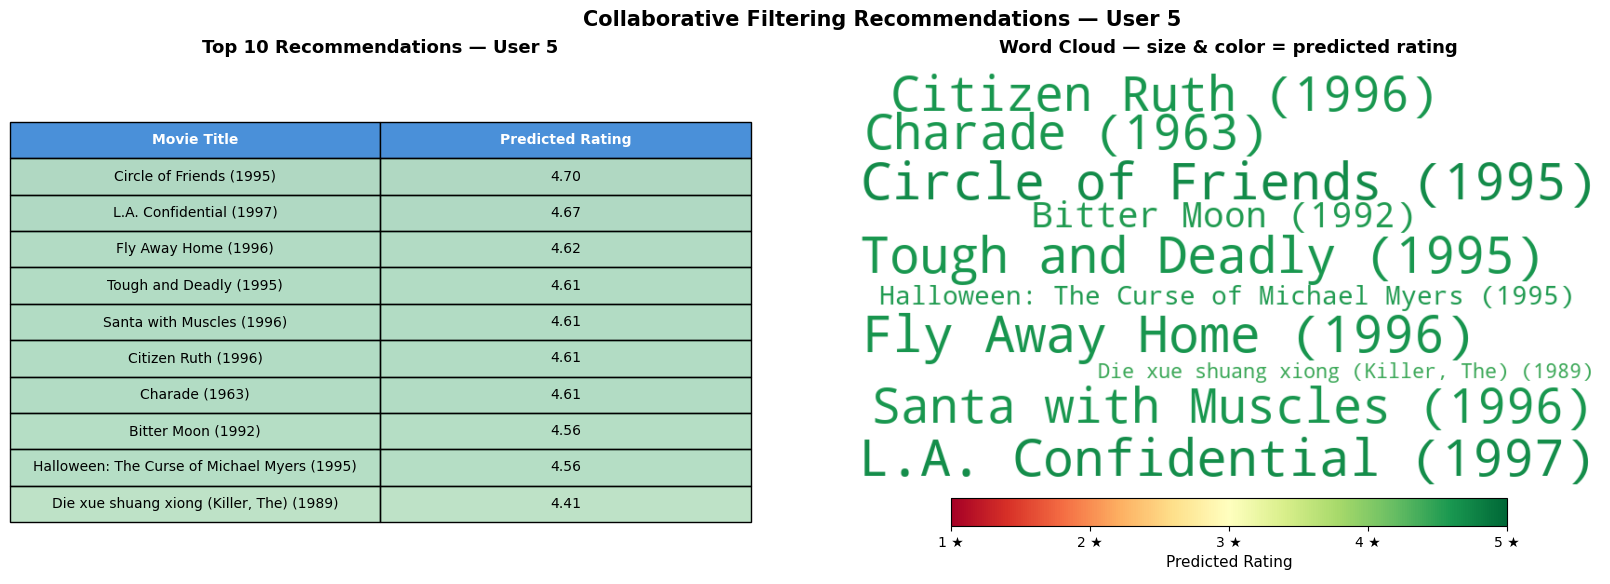

In [27]:
plot_recommendations_side_by_side(user_id=5)

### User Similarity Heatmap (Top 20 Users)

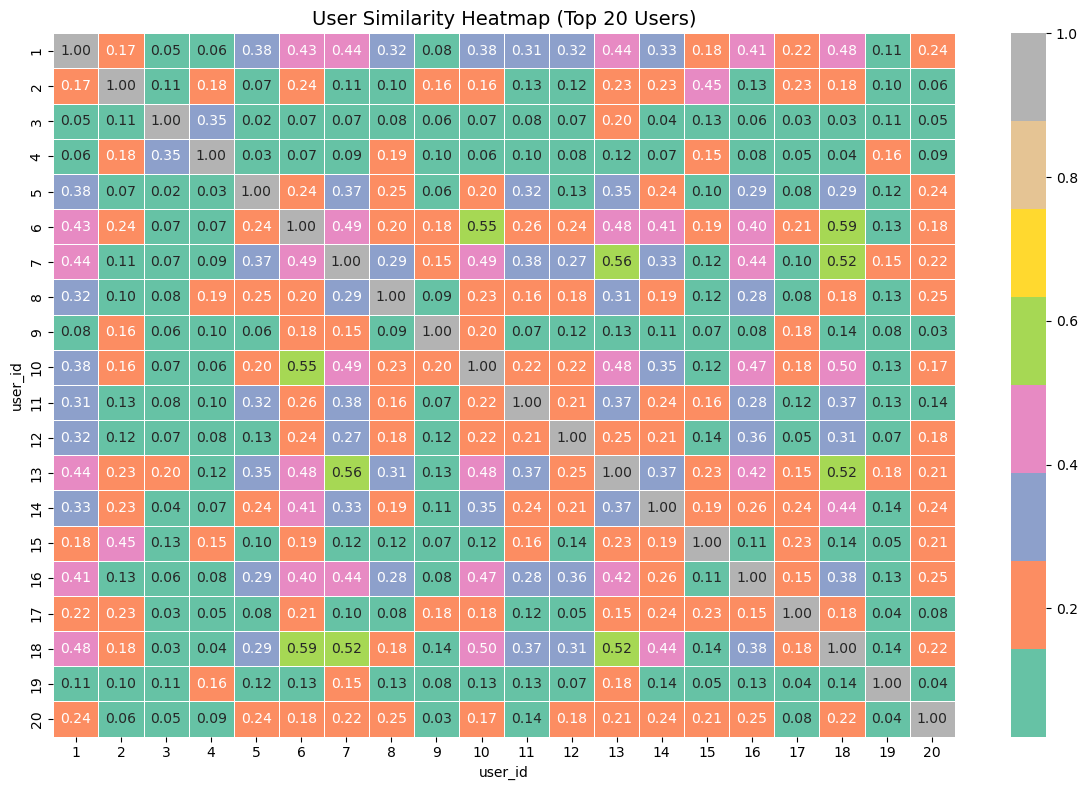

In [40]:
plt.figure(figsize=(12, 8))
sns.heatmap(user_sim_df.iloc[:20, :20],cmap='Set2',annot=True,fmt='.2f',linewidths=0.5)
plt.title("User Similarity Heatmap (Top 20 Users)", fontsize=14)
plt.tight_layout()
plt.show()

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3>📝 Summary</h3>
</div>

<div style="background-color: #f0f4f8; padding: 20px; border-radius: 10px; border-left: 5px solid #3498db;">

<h4>🤝 Approach</h4>
<ul>
    <li>Built a <strong>user × movie ratings matrix</strong> from raw ratings data</li>
    <li>Computed <strong>cosine similarity</strong> between all users</li>
    <li>For each user, found the <strong>top-N most similar users</strong></li>
    <li>Predicted ratings using <strong>similarity-weighted average</strong> of similar users' ratings</li>
    <li>Recommended movies not yet seen by the target user</li>
</ul>

<h4>📊 Key Findings</h4>
<ul>
    <li>Most users rated between 20–100 movies — enough overlap for meaningful similarity</li>
    <li>Ratings skew positive — users tend to rate movies they liked</li>
    <li>Popular movies like Star Wars and Fargo appear frequently in recommendations</li>
</ul>

</div>